In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph

In [2]:
class AgentState(TypedDict):
    name: str
    age: str
    final: str

In [3]:
def first_node(state: AgentState) -> AgentState:
    """This is the first node of the sequence"""
    state["final"] = f"Hi {state['name']}!"
    return state

def second_node(state: AgentState) -> AgentState:
    """This is the second node of the sequence"""
    state["final"] = f"{state['final']} Your age is {state['age']}."
    return state

In [8]:
graph = StateGraph(AgentState)
graph.add_node("first_node", first_node)
graph.add_node("second_node", second_node)
graph.add_edge("first_node", "second_node")
graph.set_entry_point("first_node")
graph.set_finish_point("second_node")

app = graph.compile()

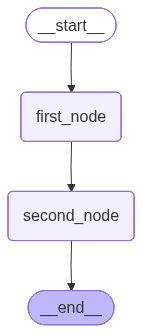

In [9]:
app

In [13]:
result = app.invoke({'name': 'Charlie', 'age': '40'}, output_keys="final")
result

'Hi Charlie! Your age is 40.'